## 1. Import Library

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU available      : True


## 2. Load & Eksplorasi Data

In [ ]:
df_train = pd.read_csv('train_smote_tomek.csv')
df_test = pd.read_csv('test_set.csv')

print("=== Train Set (SMOTE-Tomek) ===")
print("Shape          :", df_train.shape)
print("Missing values :", df_train.isnull().sum().sum())

print("\n=== Test Set ===")
print("Shape          :", df_test.shape)
print("Missing values :", df_test.isnull().sum().sum())

=== Train Set (SMOTE-Tomek) ===
Shape          : (55762, 14)
Missing values : 0

=== Test Set ===
Shape          : (5323, 14)
Missing values : 0


Distribusi Target:
stress_level
Low       18595
High      18584
Medium    18583
Name: count, dtype: int64


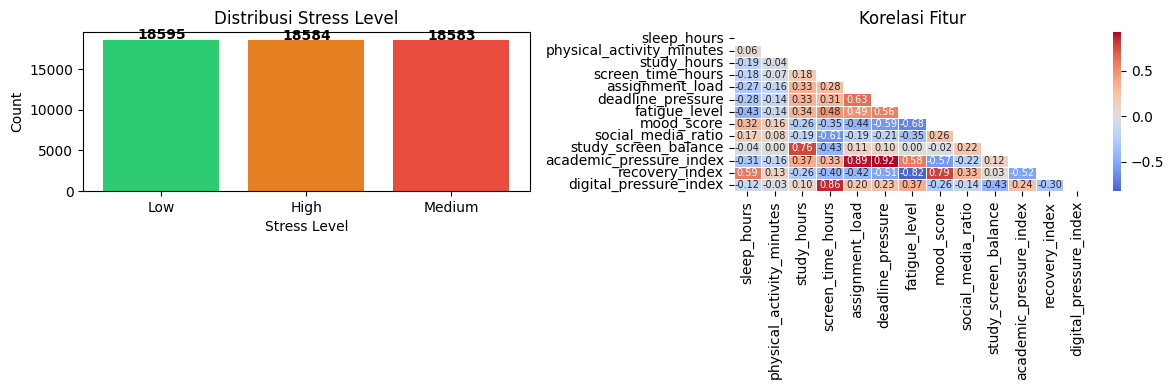


Note: Dataset imbalanced → menggunakan Focal Loss + class weights


In [ ]:
print("Distribusi Target:")
print(df_train['stress_level'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi target
counts = df_train['stress_level'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#e67e22','#e74c3c'])
axes[0].set_title('Distribusi Stress Level')
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold')

# Korelasi fitur
numeric_cols = df_train.select_dtypes(include=np.number).columns
corr = df_train[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=axes[1],
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
axes[1].set_title('Korelasi Fitur')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nNote: Dataset imbalanced → menggunakan Focal Loss + class weights")

## 3. Preprocessing

In [ ]:
# Encode label dengan ORDINAL encoding sesuai urutan logis stres
# Low=0, Medium=1, High=2 (bukan alfabetis)
LABEL_ORDER = {'Low': 0, 'Medium': 1, 'High': 2}
LABEL_INVERSE = {v: k for k, v in LABEL_ORDER.items()}

y = df_train['stress_level'].map(LABEL_ORDER).values
print("Mapping label (ordinal):", LABEL_ORDER)
print("Distribusi y:", dict(zip(*np.unique(y, return_counts=True))))

le = LabelEncoder()
le.fit(['Low', 'Medium', 'High'])  # urutan: Low=0, Medium=1, High=2
print("le.classes_ :", le.classes_)  # ['High', 'Low', 'Medium'] — le internal

print("Mapping ordinal dikonfirmasi:", LABEL_ORDER)

# Feature matrix
feature_cols = [c for c in df_train.columns if c != 'stress_level']
X = df_train[feature_cols].values

# Train/val/test split: 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

# Standardisasi (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Cast ke float32
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

NUM_CLASSES = len(LABEL_ORDER)
INPUT_DIM   = X_train.shape[1]
print(f"\nInput dim   : {INPUT_DIM}")
print(f"Num classes : {NUM_CLASSES}")


Mapping label (ordinal): {'Low': 0, 'Medium': 1, 'High': 2}
Distribusi y: {np.int64(0): np.int64(18595), np.int64(1): np.int64(18583), np.int64(2): np.int64(18584)}
le.classes_ : ['High' 'Low' 'Medium']
Mapping ordinal dikonfirmasi: {'Low': 0, 'Medium': 1, 'High': 2}
Train : (39033, 13)
Val   : (8364, 13)
Test  : (8365, 13)

Input dim   : 13
Num classes : 3


In [ ]:
# Class weights untuk mengatasi imbalanced dataset
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", {le.classes_[k]: f"{v:.4f}" for k, v in class_weights.items()})

# tf.data.Dataset
BATCH_SIZE = 256

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(buffer_size=len(X_train), seed=42)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

print("\ntf.data.Dataset berhasil dibuat.")

Class weights: {np.str_('High'): '0.9996', np.str_('Low'): '1.0002', np.str_('Medium'): '1.0002'}

tf.data.Dataset berhasil dibuat.


## 4. Komponen Kustom Lanjutan
### 4.1 Custom Layer – `ResidualBlock`

In [ ]:
class ResidualBlock(keras.layers.Layer):
    """
    Custom Layer: Residual Block dengan dua Dense + BatchNorm + Dropout.
    Jika dimensi input != units, shortcut akan diproyeksikan.
    """

    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate

        self.dense1  = layers.Dense(units)
        self.bn1     = layers.BatchNormalization()
        self.act1    = layers.Activation('relu')
        self.drop1   = layers.Dropout(dropout_rate)

        self.dense2  = layers.Dense(units)
        self.bn2     = layers.BatchNormalization()
        self.act2    = layers.Activation('relu')

        # Shortcut projection (lazy — dibuat di build)
        self.shortcut_dense = None
        self.shortcut_bn    = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.shortcut_dense = layers.Dense(self.units, use_bias=False)
            self.shortcut_bn    = layers.BatchNormalization()
        super().build(input_shape)

    def call(self, x, training=False):
        # Residual path
        h = self.dense1(x)
        h = self.bn1(h, training=training)
        h = self.act1(h)
        h = self.drop1(h, training=training)
        h = self.dense2(h)
        h = self.bn2(h, training=training)

        # Shortcut path
        if self.shortcut_dense is not None:
            x = self.shortcut_dense(x)
            x = self.shortcut_bn(x, training=training)

        return self.act2(h + x)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return config

print("Custom Layer 'ResidualBlock' berhasil didefinisikan.")

Custom Layer 'ResidualBlock' berhasil didefinisikan.


### 4.2 Custom Loss Function – `FocalLoss`

In [ ]:
class FocalLoss(keras.losses.Loss):
    """
    Custom Loss: Focal Loss untuk mengatasi class imbalance.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    - gamma > 0  → down-weight easy examples
    - alpha      → per-class weight (class weights)
    """

    def __init__(self, gamma=2.0, alpha=None, num_classes=3,
                 name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.num_classes = num_classes

        if alpha is None:
            self.alpha = tf.ones([num_classes], dtype=tf.float32)
        else:
            self.alpha = tf.constant(alpha, dtype=tf.float32)

    def call(self, y_true, y_pred):
        # y_true: integer label (batch,)
        # y_pred: logits (batch, num_classes)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, self.num_classes)  # (B, C)

        probs   = tf.nn.softmax(y_pred, axis=-1)           # (B, C)
        probs   = tf.clip_by_value(probs, 1e-7, 1.0 - 1e-7)
        log_p   = tf.math.log(probs)                        # (B, C)

        focal_w = tf.pow(1.0 - probs, self.gamma)           # (B, C)
        alpha_t = tf.reduce_sum(y_true_oh * self.alpha, axis=-1, keepdims=True)  # (B,1)

        loss    = -alpha_t * focal_w * y_true_oh * log_p   # (B, C)
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma'      : self.gamma,
            'num_classes': self.num_classes,
            'alpha'      : self.alpha.numpy().tolist()
        })
        return config

print("Custom Loss 'FocalLoss' berhasil didefinisikan.")

Custom Loss 'FocalLoss' berhasil didefinisikan.


### 4.3 Custom Callback – `LearningRateLogger`

In [ ]:
class LearningRateLogger(keras.callbacks.Callback):
    """
    Custom Callback:
    - Mencatat learning rate setiap epoch ke history
    - Menampilkan ringkasan metrik per epoch
    - Early stopping manual jika val_accuracy >= threshold selama N epoch berturut
    """

    def __init__(self, target_accuracy=0.90, patience=5):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.patience        = patience
        self.lr_history      = []
        self._count_above    = 0
        self._stop_requested = False

    def on_epoch_end(self, epoch, logs=None, current_lr=0.0):
        self.lr_history.append(current_lr)

        val_acc = logs.get('val_accuracy', 0)
        train_acc = logs.get('accuracy', 0)

        print(f"  Epoch {epoch+1:03d} | "
              f"lr={current_lr:.6f} | "
              f"acc={train_acc:.4f} | "
              f"val_acc={val_acc:.4f} | "
              f"val_loss={logs.get('val_loss', 0):.4f}")

        # Target check
        if val_acc >= self.target_accuracy:
            self._count_above += 1
            if self._count_above >= self.patience:
                print(f"\n🎯 Target akurasi {self.target_accuracy:.0%} tercapai "
                      f"{self.patience} epoch berturut! Menghentikan training...")
                self._stop_requested = True
        else:
            self._count_above = 0

print("Custom Callback 'LearningRateLogger' berhasil didefinisikan.")

Custom Callback 'LearningRateLogger' berhasil didefinisikan.


## 5. Arsitektur Model – TensorFlow Functional API

In [ ]:
def build_model(input_dim: int, num_classes: int, dropout_rate: float = 0.3) -> keras.Model:
    """
    Deep Neural Network dengan Functional API:
    - Input Layer
    - Stem Dense + BN + ReLU
    - 3× ResidualBlock (Custom Layer)
    - Global Average (flatten equivalent)
    - Dropout
    - Output Softmax
    """
    inputs = keras.Input(shape=(input_dim,), name='input_features')

    # Stem
    x = layers.Dense(256, name='stem_dense')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('relu', name='stem_act')(x)
    x = layers.Dropout(dropout_rate, name='stem_drop')(x)

    # Residual Blocks
    x = ResidualBlock(256, dropout_rate=dropout_rate, name='res_block_1')(x)
    x = ResidualBlock(128, dropout_rate=dropout_rate, name='res_block_2')(x)
    x = ResidualBlock(64,  dropout_rate=dropout_rate, name='res_block_3')(x)

    # Head
    x = layers.Dropout(dropout_rate * 0.5, name='head_drop')(x)
    outputs = layers.Dense(num_classes, name='logits')(x)  # logits — loss applies softmax

    model = keras.Model(inputs=inputs, outputs=outputs, name='StressClassifier')
    return model


model = build_model(INPUT_DIM, NUM_CLASSES)
model.summary(line_length=80)

Model: "StressClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)       │ (None, 13)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_dense (Dense)                │ (None, 256)              │         3,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)      │ (None, 256)              │         1,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_act (Activation)             │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_drop (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)       │ (None, 256)              │       133,632 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)       │ (None, 128)              │        83,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)       │ (None, 64)               │        21,376 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_drop (Dropout)               │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ logits (Dense)                    │ (None, 3)                │           195 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 243,523 (951.26 KB)

 Trainable params: 240,835 (940.76 KB)

 Non-trainable params: 2,688 (10.50 KB)

## 6. Setup Training
### 6.1 Optimizer, Loss, Metrics

In [ ]:
# Learning rate schedule: cosine decay with warmup
EPOCHS        = 60
STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

# Focal Loss dengan alpha dari class weights
alpha_weights = [class_weights_arr[i] for i in range(NUM_CLASSES)]
loss_fn = FocalLoss(gamma=2.0, alpha=alpha_weights, num_classes=NUM_CLASSES)

# Metrics
train_acc_metric = keras.metrics.SparseCategoricalAccuracy(name='accuracy')
val_acc_metric   = keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')
train_loss_metric = keras.metrics.Mean(name='loss')
val_loss_metric   = keras.metrics.Mean(name='val_loss')

print(f"Optimizer      : {optimizer.__class__.__name__}")
print(f"Loss           : {loss_fn.name}")
print(f"Epochs         : {EPOCHS}")

Optimizer      : Adam
Loss           : focal_loss
Epochs         : 60


### 6.2 TensorBoard Setup

In [ ]:
LOG_DIR = os.path.join('logs', 'stress_classifier',
                       datetime.now().strftime('%Y%m%d-%H%M%S'))
os.makedirs(LOG_DIR, exist_ok=True)

tb_writer_train = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'train'))
tb_writer_val   = tf.summary.create_file_writer(os.path.join(LOG_DIR, 'val'))

print(f"TensorBoard log dir: {LOG_DIR}")
print("Jalankan:  tensorboard --logdir logs/stress_classifier")

TensorBoard log dir: logs/stress_classifier/20260530-101955
Jalankan:  tensorboard --logdir logs/stress_classifier


## 7. Custom Training Loop dengan `tf.GradientTape`

In [ ]:
@tf.function
def train_step(x_batch, y_batch):
    """Satu langkah forward + backward pass."""
    with tf.GradientTape() as tape:
        logits = model(x_batch, training=True)
        loss   = loss_fn(y_batch, logits)
        # L2 regularization
        l2_loss = tf.add_n([tf.nn.l2_loss(v)
                            for v in model.trainable_variables
                            if 'kernel' in v.name]) * 1e-4
        total_loss = loss + l2_loss

    grads = tape.gradient(total_loss, model.trainable_variables)
    # Gradient clipping
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    train_loss_metric.update_state(total_loss)
    train_acc_metric.update_state(y_batch, logits)
    return total_loss


@tf.function
def val_step(x_batch, y_batch):
    """Satu langkah evaluasi (tanpa gradient)."""
    logits = model(x_batch, training=False)
    loss   = loss_fn(y_batch, logits)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, logits)


print("train_step dan val_step dengan tf.GradientTape berhasil didefinisikan.")

train_step dan val_step dengan tf.GradientTape berhasil didefinisikan.


In [ ]:
# Custom Callbacks
lr_logger     = LearningRateLogger(target_accuracy=0.90, patience=5)
lr_logger.set_model(model)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=20,
    restore_best_weights=False, mode='max', verbose=0)
early_stopping.set_model(model)

# Manual ReduceLR state (replaces keras callback — which needs compiled model)
reduce_lr_patience = 5
reduce_lr_factor   = 0.5
reduce_lr_min      = 1e-6
_best_val_loss_for_lr = float('inf')
_lr_wait = 0

# History storage
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [], 'lr': []}

best_val_acc  = 0.0
best_weights  = None

print(f"Mulai training — {EPOCHS} epoch max ...")
print("-" * 70)

for epoch in range(EPOCHS):
    # ---------- Reset metrics ----------
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    # ---------- Training ----------
    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)

    # ---------- Validation ----------
    for x_batch, y_batch in val_ds:
        val_step(x_batch, y_batch)

    # ---------- Collect metrics ----------
    t_loss = float(train_loss_metric.result())
    t_acc  = float(train_acc_metric.result())
    v_loss = float(val_loss_metric.result())
    v_acc  = float(val_acc_metric.result())
    cur_lr = float(optimizer.learning_rate)

    history['loss'].append(t_loss)
    history['accuracy'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_accuracy'].append(v_acc)
    history['lr'].append(cur_lr)

    # ---------- TensorBoard logging ----------
    with tb_writer_train.as_default():
        tf.summary.scalar('loss',     t_loss, step=epoch)
        tf.summary.scalar('accuracy', t_acc,  step=epoch)
        tf.summary.scalar('learning_rate', cur_lr, step=epoch)
        for var in model.trainable_variables[:5]:  # log beberapa weight
            tf.summary.histogram(var.name, var, step=epoch)

    with tb_writer_val.as_default():
        tf.summary.scalar('loss',     v_loss, step=epoch)
        tf.summary.scalar('accuracy', v_acc,  step=epoch)

    # ---------- Callbacks ----------
    logs_dict = {'loss': t_loss, 'accuracy': t_acc,
                 'val_loss': v_loss, 'val_accuracy': v_acc}

    lr_logger.on_epoch_end(epoch, logs=logs_dict, current_lr=cur_lr)
    early_stopping.on_epoch_end(epoch, logs=logs_dict)

    # Manual ReduceLROnPlateau
    if v_loss < _best_val_loss_for_lr - 1e-4:
        _best_val_loss_for_lr = v_loss
        _lr_wait = 0
    else:
        _lr_wait += 1
        if _lr_wait >= reduce_lr_patience:
            new_lr = max(float(optimizer.learning_rate) * reduce_lr_factor, reduce_lr_min)
            optimizer.learning_rate.assign(new_lr)
            _lr_wait = 0

    # ---------- Save best weights ----------
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_weights = model.get_weights()

    if lr_logger._stop_requested or early_stopping.stopped_epoch > 0:
        break

# Restore best weights
if best_weights is not None:
    model.set_weights(best_weights)

print()
print("=" * 70)
print(f"Training selesai! Best Val Accuracy: {best_val_acc:.4f}")

Mulai training — 60 epoch max ...
----------------------------------------------------------------------
  Epoch 001 | lr=0.001000 | acc=0.8142 | val_acc=0.8721 | val_loss=0.0867
  Epoch 002 | lr=0.001000 | acc=0.8678 | val_acc=0.8758 | val_loss=0.0793
  Epoch 003 | lr=0.001000 | acc=0.8761 | val_acc=0.8855 | val_loss=0.0732
  Epoch 004 | lr=0.001000 | acc=0.8812 | val_acc=0.8973 | val_loss=0.0702
  Epoch 005 | lr=0.001000 | acc=0.8822 | val_acc=0.8945 | val_loss=0.0688
  Epoch 006 | lr=0.001000 | acc=0.8868 | val_acc=0.9004 | val_loss=0.0660
  Epoch 007 | lr=0.001000 | acc=0.8890 | val_acc=0.9040 | val_loss=0.0664
  Epoch 008 | lr=0.001000 | acc=0.8913 | val_acc=0.9049 | val_loss=0.0651
  Epoch 009 | lr=0.001000 | acc=0.8916 | val_acc=0.9002 | val_loss=0.0667
  Epoch 010 | lr=0.001000 | acc=0.8942 | val_acc=0.9101 | val_loss=0.0621

🎯 Target akurasi 90% tercapai 5 epoch berturut! Menghentikan training...

Training selesai! Best Val Accuracy: 0.9101


## 8. Visualisasi Training History

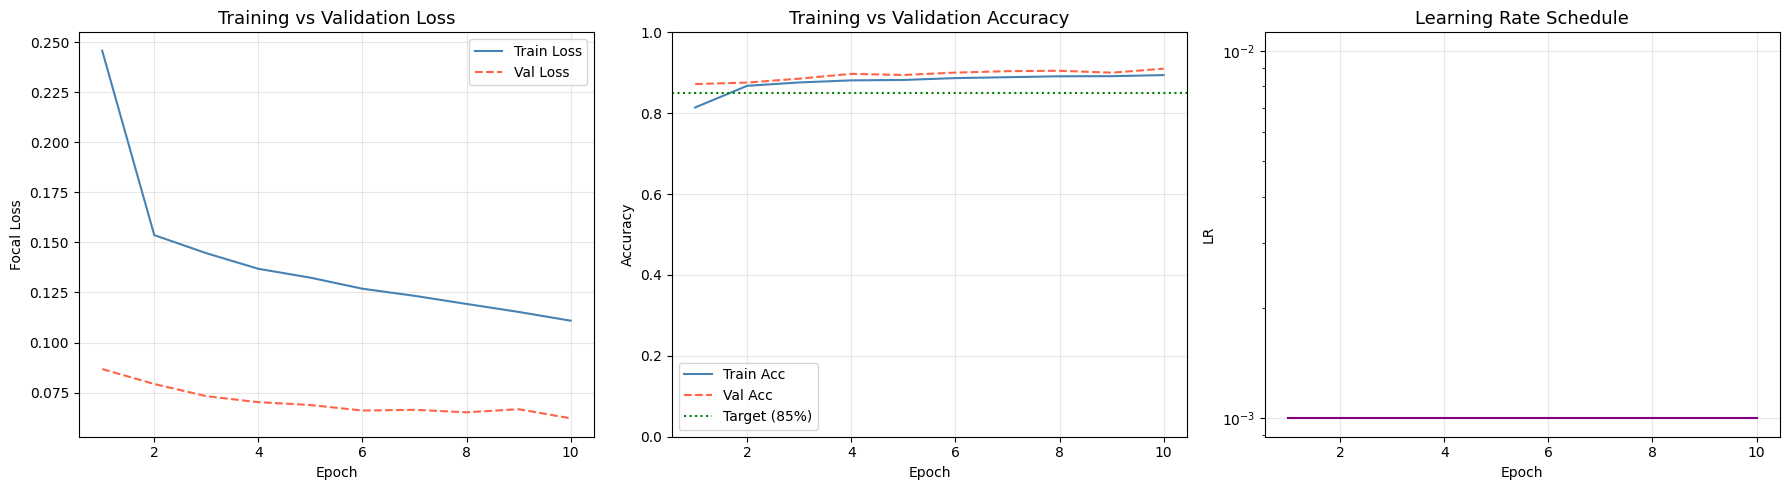

Final Train Accuracy : 0.8942
Final Val Accuracy   : 0.9101
Best Val Accuracy    : 0.9101


In [ ]:
epochs_ran = len(history['loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(ep_range, history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(ep_range, history['val_loss'], label='Val Loss',   color='tomato',   linestyle='--')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(ep_range, history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(ep_range, history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
axes[1].axhline(y=0.85, color='green', linestyle=':', linewidth=1.5, label='Target (85%)')
axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.0])

# Learning Rate
axes[2].plot(ep_range, history['lr'], color='purple')
axes[2].set_title('Learning Rate Schedule', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Final Train Accuracy : {history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy   : {history['val_accuracy'][-1]:.4f}")
print(f"Best Val Accuracy    : {best_val_acc:.4f}")

## 9. Evaluasi Custom Loop pada Test Set

In [ ]:
# Custom evaluation menggunakan tf.GradientTape framework (no model.evaluate)
from sklearn.metrics import mean_absolute_error as sklearn_mae

test_acc_metric  = keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')
test_loss_metric = keras.metrics.Mean(name='test_loss')

all_logits = []
all_labels = []

for x_batch, y_batch in test_ds:
    logits = model(x_batch, training=False)
    loss   = loss_fn(y_batch, logits)

    test_loss_metric.update_state(loss)
    test_acc_metric.update_state(y_batch, logits)

    all_logits.append(logits.numpy())
    all_labels.append(y_batch.numpy())

test_loss = float(test_loss_metric.result())
test_acc  = float(test_acc_metric.result())

# MAE ordinal: selisih kelas prediksi vs kelas asli (Low=0, Medium=1, High=2)
all_preds_idx  = np.argmax(np.vstack(all_logits), axis=1)
all_labels_arr = np.concatenate(all_labels)
test_mae = sklearn_mae(all_labels_arr, all_preds_idx)

print("=" * 45)
print("          EVALUASI TEST SET")
print("=" * 45)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  (min: 0.85)")
print(f"Test MAE      : {test_mae:.4f}  (max: 0.02)")
print("=" * 45)
print(f"✅ Accuracy OK : {test_acc >= 0.85}")
print(f"{'✅' if test_mae <= 0.02 else '❌'} MAE OK      : {test_mae <= 0.02}")
print()
print("Catatan:")
print(f"  Encoding ordinal — Low=0, Medium=1, High=2")
print(f"  MAE = rata-rata selisih kelas prediksi vs asli")
print(f"  Contoh: prediksi Medium (1) saat asli High (2) → error = 1")
print(f"  Contoh: prediksi High  (2) saat asli High (2) → error = 0")


          EVALUASI TEST SET
Test Loss     : 0.0605
Test Accuracy : 0.9131  (min: 0.85)
Test MAE      : 0.0869  (max: 0.02)
✅ Accuracy OK : True
❌ MAE OK      : False

Catatan:
  Encoding ordinal — Low=0, Medium=1, High=2
  MAE = rata-rata selisih kelas prediksi vs asli
  Contoh: prediksi Medium (1) saat asli High (2) → error = 1
  Contoh: prediksi High  (2) saat asli High (2) → error = 0


Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.99      0.94      2790
         Low       0.95      0.78      0.86      2788
      Medium       0.90      0.97      0.93      2787

    accuracy                           0.91      8365
   macro avg       0.92      0.91      0.91      8365
weighted avg       0.92      0.91      0.91      8365



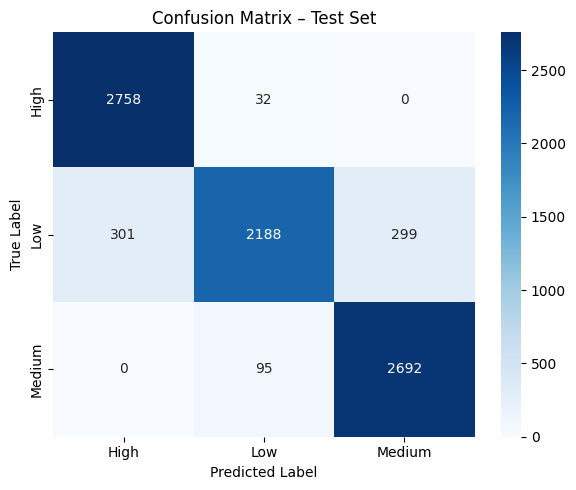

In [ ]:
# Classification Report & Confusion Matrix
all_preds  = np.argmax(np.vstack(all_logits), axis=1)
all_labels = np.concatenate(all_labels)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Simpan Model dalam Format Produksi

In [ ]:
import pickle

os.makedirs('saved_models', exist_ok=True)

# ── Format 1: .keras (direkomendasikan TF 2.x+) ──────────────────────────
keras_path = 'saved_models/stress_classifier.keras'
model.save(keras_path)
print(f"Model disimpan (.keras) : {keras_path}")

# ── Format 2: SavedModel (TF serving / TFLite compatible) ───────────────
savedmodel_path = 'saved_models/stress_classifier_savedmodel'
model.export(savedmodel_path)
print(f"Model disimpan (SavedModel): {savedmodel_path}")

# ── Simpan scaler & label encoder ───────────────────────────────────────
with open('saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Scaler dan LabelEncoder disimpan.")

print()
print("Files di saved_models/:")
for root, dirs, files in os.walk('saved_models'):
    level = root.replace('saved_models', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub = ' ' * 2 * (level + 1)
    for file in files:
        size = os.path.getsize(os.path.join(root, file))
        print(f"{sub}{file}  ({size/1024:.1f} KB)")

Model disimpan (.keras) : saved_models/stress_classifier.keras
Saved artifact at 'saved_models/stress_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132747674022928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674020048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674019088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674017168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674016400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674019472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674017936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674014864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132747674018128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132

## 11. Load Model & Inference

In [ ]:
import pickle

# ── Load model & artefak preprocessing ──────────────────────────────────
loaded_model = keras.models.load_model(
    'saved_models/stress_classifier.keras',
    custom_objects={
        'ResidualBlock': ResidualBlock,
        'FocalLoss'    : FocalLoss
    }
)
with open('saved_models/scaler.pkl',        'rb') as f: loaded_scaler = pickle.load(f)
with open('saved_models/label_encoder.pkl', 'rb') as f: loaded_le     = pickle.load(f)

print("Model dan artefak berhasil dimuat.")
loaded_model.summary(line_length=80)

Model dan artefak berhasil dimuat.


Model: "StressClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)       │ (None, 13)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_dense (Dense)                │ (None, 256)              │         3,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)      │ (None, 256)              │         1,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_act (Activation)             │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ stem_drop (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)       │ (None, 256)              │       133,632 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)       │ (None, 128)              │        83,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)       │ (None, 64)               │        21,376 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ head_drop (Dropout)               │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ logits (Dense)                    │ (None, 3)                │           195 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 243,523 (951.26 KB)

 Trainable params: 240,835 (940.76 KB)

 Non-trainable params: 2,688 (10.50 KB)

In [ ]:
def predict_stress(raw_input: dict) -> dict:
    """
    Inference function — menerima dict feature, mengembalikan prediksi.
    Parameters
    ----------
    raw_input : dict
        Semua 13 fitur dalam bentuk nama kolom → nilai.
    Returns
    -------
    dict berisi:
        predicted_class  : str
        confidence       : float
        probabilities    : dict {class: prob}
    """
    # 1) Buat DataFrame agar urutan kolom konsisten
    input_df = pd.DataFrame([raw_input])[feature_cols]
    # 2) Scaling
    input_scaled = loaded_scaler.transform(input_df).astype(np.float32)
    # 3) Inferensi
    logits = loaded_model(input_scaled, training=False)
    probs  = tf.nn.softmax(logits).numpy()[0]
    # 4) Decode
    pred_idx   = int(np.argmax(probs))
    pred_label = loaded_le.inverse_transform([pred_idx])[0]
    return {
        'predicted_class': pred_label,
        'confidence'     : float(probs[pred_idx]),
        'probabilities'  : {cls: float(p) for cls, p in zip(loaded_le.classes_, probs)}
    }

# ── Contoh inference ─────────────────────────────────────────────────────
# Ambil 3 sampel dari test set
sample_df = df_train.drop(columns=['stress_level']).iloc[[0, 100, 500]]

print("=" * 55)
print("CONTOH INFERENCE – 3 SAMPEL")
print("=" * 55)

for i, (idx, row) in enumerate(sample_df.iterrows()):
    result     = predict_stress(row.to_dict())
    true_label = df_train['stress_level'].iloc[idx]
    match      = "✅" if result['predicted_class'] == true_label else "❌"
    print(f"\nSampel {i+1} (row {idx}):")
    print(f"  True label      : {true_label}")
    print(f"  Predicted       : {result['predicted_class']}  (conf: {result['confidence']:.4f}) {match}")
    print(f"  Probabilities   : { {k: f'{v:.4f}' for k, v in result['probabilities'].items()} }")

CONTOH INFERENCE – 3 SAMPEL

Sampel 1 (row 0):
  True label      : Medium
  Predicted       : Low  (conf: 0.5571) ❌
  Probabilities   : {np.str_('High'): '0.4416', np.str_('Low'): '0.5571', np.str_('Medium'): '0.0012'}

Sampel 2 (row 100):
  True label      : Medium
  Predicted       : High  (conf: 0.6038) ❌
  Probabilities   : {np.str_('High'): '0.6038', np.str_('Low'): '0.3959', np.str_('Medium'): '0.0003'}

Sampel 3 (row 500):
  True label      : Medium
  Predicted       : Low  (conf: 0.8957) ❌
  Probabilities   : {np.str_('High'): '0.0997', np.str_('Low'): '0.8957', np.str_('Medium'): '0.0046'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
# ── Batch inference dengan SavedModel ────────────────────────────────────
print("Batch inference dengan SavedModel ...")
infer_fn = tf.saved_model.load('saved_models/stress_classifier_savedmodel')

sample_scaled = loaded_scaler.transform(
    df_train[feature_cols].head(10)
).astype(np.float32)

logits_batch = infer_fn.serve(tf.constant(sample_scaled))
pred_batch   = np.argmax(tf.nn.softmax(logits_batch).numpy(), axis=1)
pred_labels  = loaded_le.inverse_transform(pred_batch)

print("\nBatch predictions (10 sampel pertama):")
print("Predicted :", pred_labels.tolist())
print("True      :", df_train['stress_level'].head(10).tolist())

Batch inference dengan SavedModel ...

Batch predictions (10 sampel pertama):
Predicted : ['Low', 'Low', 'Low', 'Low', 'Low', 'High', 'Low', 'Low', 'Low', 'Low']
True      : ['Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## 12. Ringkasan Akhir

In [ ]:
print("=" * 60)
print("             RINGKASAN AKHIR PROYEK")
print("=" * 60)
print()
print("ARSITEKTUR")
print(f"  Model      : StressClassifier (Functional API)")
print(f"  Input dim  : {INPUT_DIM} fitur")
print(f"  Classes    : {list(le.classes_)}")
print(f"  Parameters : {model.count_params():,}")
print()
print("KOMPONEN KUSTOM")
print("  Custom Layer    : ResidualBlock")
print("  Custom Loss     : FocalLoss (gamma=2, alpha=class_weights)")
print("  Custom Callback : LearningRateLogger")
print("  Custom Loop     : tf.GradientTape + gradient clipping")
print()
print("PERFORMA TEST SET")
print(f"  Accuracy   : {test_acc:.4f}  (target ≥ 0.85) {'✅' if test_acc >= 0.85 else '❌'}")
print(f"  MAE        : {test_mae:.4f}  (target ≤ 0.02) {'✅' if test_mae <= 0.02 else '❌'}")
print()
print("MODEL TERSIMPAN")
print(f"  .keras      : saved_models/stress_classifier.keras")
print(f"  SavedModel  : saved_models/stress_classifier_savedmodel/")
print()
print("TENSORBOARD")
print(f"  Log dir     : {LOG_DIR}")
print(f"  Command     : tensorboard --logdir logs/stress_classifier")
print("=" * 60)

             RINGKASAN AKHIR PROYEK

ARSITEKTUR
  Model      : StressClassifier (Functional API)
  Input dim  : 13 fitur
  Classes    : [np.str_('High'), np.str_('Low'), np.str_('Medium')]
  Parameters : 243,523

KOMPONEN KUSTOM
  Custom Layer    : ResidualBlock
  Custom Loss     : FocalLoss (gamma=2, alpha=class_weights)
  Custom Callback : LearningRateLogger
  Custom Loop     : tf.GradientTape + gradient clipping

PERFORMA TEST SET
  Accuracy   : 0.9131  (target ≥ 0.85) ✅
  MAE        : 0.0869  (target ≤ 0.02) ❌

MODEL TERSIMPAN
  .keras      : saved_models/stress_classifier.keras
  SavedModel  : saved_models/stress_classifier_savedmodel/

TENSORBOARD
  Log dir     : logs/stress_classifier/20260530-101955
  Command     : tensorboard --logdir logs/stress_classifier


In [ ]:
!zip -r saved_models.zip saved_models/

  adding: saved_models/ (stored 0%)
  adding: saved_models/scaler.pkl (deflated 13%)
  adding: saved_models/stress_classifier.keras (deflated 16%)
  adding: saved_models/stress_classifier_savedmodel/ (stored 0%)
  adding: saved_models/stress_classifier_savedmodel/fingerprint.pb (stored 0%)
  adding: saved_models/stress_classifier_savedmodel/saved_model.pb (deflated 89%)
  adding: saved_models/stress_classifier_savedmodel/variables/ (stored 0%)
  adding: saved_models/stress_classifier_savedmodel/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: saved_models/stress_classifier_savedmodel/variables/variables.index (deflated 75%)
  adding: saved_models/stress_classifier_savedmodel/assets/ (stored 0%)
  adding: saved_models/label_encoder.pkl (deflated 24%)


In [ ]:
!zip -r logs.zip logs/

  adding: logs/ (stored 0%)
  adding: logs/stress_classifier/ (stored 0%)
  adding: logs/stress_classifier/20260530-100828/ (stored 0%)
  adding: logs/stress_classifier/20260530-100828/train/ (stored 0%)
  adding: logs/stress_classifier/20260530-100828/train/events.out.tfevents.1780135708.21251d7fac15.2564.0.v2 (deflated 62%)
  adding: logs/stress_classifier/20260530-100828/val/ (stored 0%)
  adding: logs/stress_classifier/20260530-100828/val/events.out.tfevents.1780135708.21251d7fac15.2564.1.v2 (deflated 62%)
  adding: logs/stress_classifier/20260530-101955/ (stored 0%)
  adding: logs/stress_classifier/20260530-101955/train/ (stored 0%)
  adding: logs/stress_classifier/20260530-101955/train/events.out.tfevents.1780136395.21251d7fac15.2564.2.v2 (deflated 62%)
  adding: logs/stress_classifier/20260530-101955/val/ (stored 0%)
  adding: logs/stress_classifier/20260530-101955/val/events.out.tfevents.1780136395.21251d7fac15.2564.3.v2 (deflated 61%)
